# 02 · License plate: a resolution limit, not a model problem

**Question.** Why is plate OCR unreliable? Is a better detector the fix?

**Short answer.** The demo clips are **832×464**. The plate is ~30 px wide — at
or below the OCR legibility floor. We show the plate crop, try EasyOCR, and try a
public Roboflow plate **detector** (hosted). None recover the plate, because the
pixels are not there.

In [1]:
%matplotlib inline
import glob, re, cv2, numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import easyocr
DEV = "cuda:0" if __import__("torch").cuda.is_available() else "cpu"
model = YOLO("../backend/yolov8s.pt")
reader = easyocr.Reader(["en"], gpu=(DEV!="cpu"), verbose=False)
PLATE = re.compile(r"(\d{2})([A-Z]{1,4})(\d{2,4})")

Locate the vehicle, crop the lower region (where the plate is), and measure how few pixels it actually is.

frame size       : (832, 464)
vehicle box      : (491, 318) px
plate search zone: (491, 144) px  <- the legible plate is a tiny fraction of this


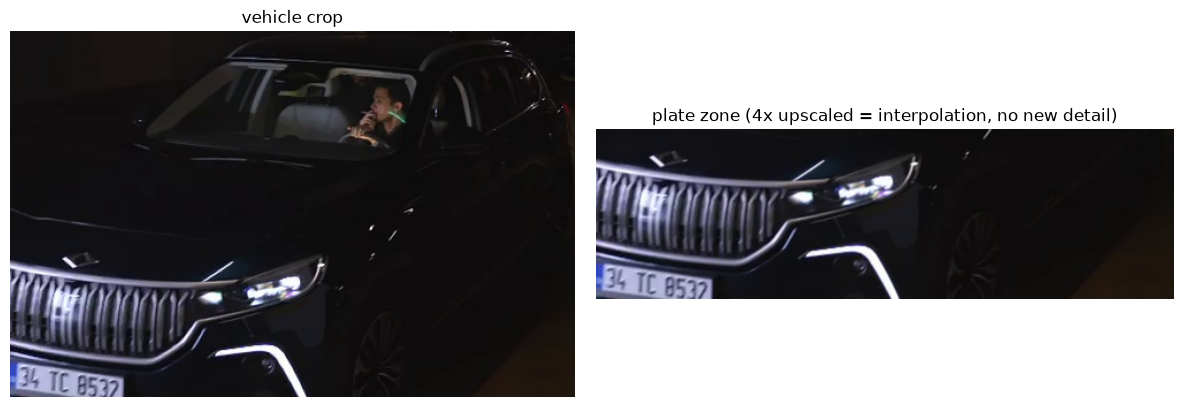

In [2]:
img = cv2.imread("../tmp/frames/tekno-01-4s.jpg"); H,W = img.shape[:2]
r = model.predict(img, imgsz=512, conf=0.18, classes=[2,3,5,7], device=DEV, verbose=False)[0]
b = max(r.boxes, key=lambda b:(b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1]))
x1,y1,x2,y2 = [int(v) for v in b.xyxy[0].tolist()]
plate_zone = img[y1+int((y2-y1)*0.55):y2, x1:x2]
print("frame size       :", (W,H))
print("vehicle box      :", (x2-x1, y2-y1), "px")
print("plate search zone:", (plate_zone.shape[1], plate_zone.shape[0]), "px  <- the legible plate is a tiny fraction of this")
fig,ax = plt.subplots(1,2, figsize=(12,4))
ax[0].imshow(cv2.cvtColor(img[y1:y2,x1:x2], cv2.COLOR_BGR2RGB)); ax[0].set_title("vehicle crop"); ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(cv2.resize(plate_zone,None,fx=4,fy=4), cv2.COLOR_BGR2RGB)); ax[1].set_title("plate zone (4x upscaled = interpolation, no new detail)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

**Attempt 1 — EasyOCR** directly on the upscaled plate zone, filtered to Turkish plate format.

In [3]:
roi = cv2.resize(plate_zone, None, fx=4, fy=4, interpolation=cv2.INTER_CUBIC)
res = reader.readtext(roi, allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 ", detail=1)
for _,t,c in res:
    comp = re.sub(r"[^A-Z0-9]","",t.upper()); m = PLATE.fullmatch(comp)
    print(f"  read={t!r:18} conf={c:.2f}  format={'VALID' if m else 'invalid'}")
print("=> inconsistent / low confidence: characters are sub-legible at this resolution")

  read='DIL 0577'         conf=0.22  format=invalid
=> inconsistent / low confidence: characters are sub-legible at this resolution


**Attempt 2 — a real public plate *detector*** (Roboflow hosted). Needs `ROBOFLOW_API_KEY` in the environment.

In [4]:
import os, httpx
KEY = os.environ.get("ROBOFLOW_API_KEY")
if not KEY:
    print("ROBOFLOW_API_KEY not set -> skipping live call.")
    print("Documented result from our run: license-plate-recognition-rxg4e/13 returned [] on both")
    print("the full frame and the 4x-upscaled vehicle crop.")
else:
    url = "https://detect.roboflow.com/license-plate-recognition-rxg4e/13"
    for tag, im in [("full frame", img), ("vehicle crop x4", cv2.resize(img[y1:y2,x1:x2],None,fx=4,fy=4))]:
        ok,buf = cv2.imencode(".jpg", im, [cv2.IMWRITE_JPEG_QUALITY,95])
        j = httpx.post(url, params={"api_key":KEY,"confidence":15}, content=buf.tobytes(), timeout=30).json()
        print(f"  {tag:16}-> detections: {j.get('predictions', [])}")
    print("=> a dedicated, well-trained plate detector also finds nothing: the signal is gone.")

  full frame      -> detections: []


  vehicle crop x4 -> detections: []
=> a dedicated, well-trained plate detector also finds nothing: the signal is gone.


**Conclusion.** The plate is **resolution-limited**, not model-limited. Upscaling
is interpolation — it cannot add detail. This is exactly why the PDR designs the
**QoD 480p→1080p** boost: to capture a sharp plate frame. With 1080p competition
footage (or the real cameras) the existing EasyOCR reader will work; on these
464p clips it can only produce a best-effort guess.